# Introduction
This notebook develops a short-horizon forecasting model for the Kaggle competition **Store Sales Time Series Forecasting**, which contains daily sales by Favorita store and product family in Ecuador. The business objective is to forecast sales for the 16-day test window immediately after the training period ends on **2017-08-15**.

These forecasts are especially relevant to brick-and-mortar grocery stores: forecast too high and stores may overstock perishable goods; forecast too low and popular items can sell out, causing lost revenue and frustrated customers. The competition metric, Root Mean Squared Logarithmic Error (RMSLE), rewards forecasts that are close in relative terms and is well aligned with this supply-chain objective.

| File | Purpose |
|---|---|
| `train.csv` | Historical daily sales by store and product family. |
| `test.csv` | Store-family-date rows requiring sales predictions. |
| `holidays_events.csv` | National and regional calendar events used as model features. |


# Exploration

`train.csv` contains one daily observation for each `store_nbr`, `family`, and `date` combination. These keys define the individual time series, and `sales` is the target variable to forecast.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

store_sales = pd.read_csv(
    'data/train.csv',
    usecols=['store_nbr', 'family', 'date', 'sales'],
    dtype={
        'store_nbr': 'category',
        'family': 'category',
        'sales': 'float32',
    },
    parse_dates=['date']
)
store_sales['date'] = store_sales.date.dt.to_period('D')
store_sales = store_sales.set_index(['store_nbr', 'family', 'date']).sort_index()
store_sales.head()


sales
store_nbr family     date             
1         AUTOMOTIVE 2013-01-01    0.0
                     2013-01-02    2.0
                     2013-01-03    3.0
                     2013-01-04    3.0
                     2013-01-05    5.0

## Trend
The data spans 2013-01-01 through 2017-08-15, while the competition asks us to forecast only the next 16 days. Older history may still help identify broad trend, but recent data should carry more weight for the final model. As a quick check, we inspect BEVERAGES sales with monthly totals and a centered 12-month moving average to smooths over short-term fluctuations.

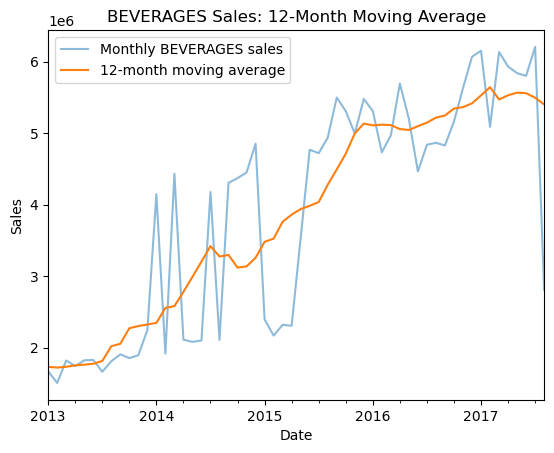

In [2]:
# Select BEVERAGES from the family index level
beverage_sales = store_sales.xs('BEVERAGES', level='family')

# Aggregate across stores by date
beverage_sales = beverage_sales.groupby('date')['sales'].sum()

# Monthly totals
beverage_sales_monthly = beverage_sales.to_timestamp().resample('MS').sum()

# 12-month moving average
trend = beverage_sales_monthly.rolling(
    window=12,
    center=True,
    min_periods=6,
).mean()

fig, ax = plt.subplots()
beverage_sales_monthly.plot(ax=ax, alpha=0.5, label='Monthly BEVERAGES sales')
trend.plot(ax=ax, label='12-month moving average')

ax.set_title('BEVERAGES Sales: 12-Month Moving Average')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend();

The BEVERAGES series is noisy month to month, but the moving average shows a clear upward trend over the training period.

## Seasonality
We zoom into 2017 to inspect seasonality closer to the forecast window, using daily average sales. The next plot uses average daily sales across store-family combinations.

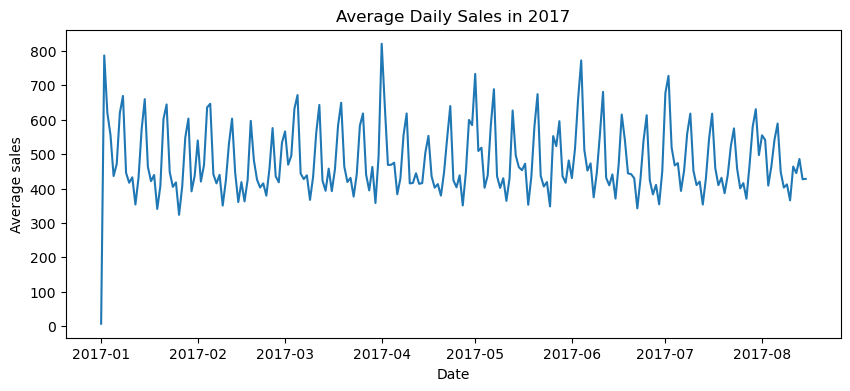

In [3]:
average_sales = (
    store_sales
    .groupby('date')['sales']
    .mean()
    .loc['2017']
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(average_sales['date'].dt.to_timestamp(), average_sales['sales'])
ax.set_title('Average Daily Sales in 2017')
ax.set_xlabel('Date')
ax.set_ylabel('Average sales');

New Year's Day is a clear outlier, and the rest of the year shows recurring calendar patterns that are worth modelling explicitly.

Some of the visible spikes align with holidays and public events. We convert the relevant entries in `data/holidays_events.csv` into dummy variables that can be joined to the deterministic calendar features.


In [4]:

holidays_events = pd.read_csv(
    "data/holidays_events.csv",
    dtype={
        'type': 'category',
        'locale': 'category',
        'locale_name': 'category',
        'description': 'category',
        'transferred': 'bool',
    },
    parse_dates=['date'],
)
holidays_events['date'] = holidays_events.date.dt.to_period('D')
holidays_events = holidays_events.set_index('date').sort_index()

holidays = (
    holidays_events
    .query("locale in ['National', 'Regional'] and transferred == False")
    .loc['2017':'2017-08-31', ['description']]
    .assign(description=lambda x: x.description.cat.remove_unused_categories())
)

X_holidays = pd.get_dummies(holidays['description'], prefix='holiday')
X_holidays = X_holidays.groupby(level='date').max().astype('float32')

def add_newyearday_feature(X):
    """Add simple calendar indicators used by the base model."""
    X = X.copy()
    X['NewYear'] = (X.index.dayofyear == 1).astype('float32')
    return X


def add_holiday_features(X):
    """Add broader holiday/event indicators from data/holidays_events.csv."""
    X = add_newyearday_feature(X)
    X = X.join(X_holidays.reindex(X.index).fillna(0.0))
    return X

X_holidays.head()


,holiday_Carnaval,holiday_Dia de la Madre,holiday_Dia de la Madre-1,holiday_Dia del Trabajo,holiday_Provincializacion de Cotopaxi,holiday_Provincializacion de Imbabura,holiday_Traslado Batalla de Pichincha,holiday_Traslado Primer Grito de Independencia,holiday_Traslado Primer dia del ano,holiday_Viernes Santo
date,,,,,,,,,,
2017-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2017-02-27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-02-28,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-04-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2017-04-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Modelling

## Baseline

As a baseline, we use a seasonal naive forecast: for each store-family pair, predict sales using the value from the same weekday one week earlier. This is a reasonable benchmark for daily retail sales because weekly shopping patterns are common. Any more complex model should improve over this baseline to justify its added complexity.

In [5]:
y = store_sales.unstack(['store_nbr', 'family']).loc['2017']

valid_start = '2017-08-01'
valid_end = '2017-08-15'
y_train = y.loc[:'2017-07-31']
y_valid = y.loc[valid_start:valid_end]

# Seasonal naive baseline: predict the same store-family sales from 7 days ago.
y_baseline = y_valid.copy()
for date in y_valid.index:
    y_baseline.loc[date] = y.loc[date - 7]

y_baseline = y_baseline.clip(lower=0)
baseline_rmsle = mean_squared_log_error(y_valid, y_baseline) ** 0.5
baseline_rmsle

0.5690269172151937

## Seasonal Model

Calendar Fourier terms, pairs of sine and cosine curves, can model smooth recurring seasonality without adding a large number of dummy variables.

The validation split uses 2017-08-01 through 2017-08-15, the final two weeks available before the test set. We tune a small grid of monthly-end (`ME`) and quarter-end (`QE`) Fourier terms, keeping the design compact to reduce overfitting across the 1,782 store-family series.

In [6]:
results = []

for freq in ['ME', 'QE']:
    for order in [1, 2, 3, 4, 5, 6, 12]:
        fourier = CalendarFourier(freq=freq, order=order)

        dp = DeterministicProcess(
            index=y_train.index,
            constant=True,
            order=1,
            seasonal=True,
            additional_terms=[fourier],
            drop=True,
        )

        X_train = add_newyearday_feature(dp.in_sample())
        X_valid = add_newyearday_feature(dp.out_of_sample(steps=len(y_valid)))

        model = LinearRegression(fit_intercept=False)
        model.fit(X_train, y_train)

        y_pred = pd.DataFrame(
            model.predict(X_valid),
            index=y_valid.index,
            columns=y_valid.columns,
        ).clip(lower=0)

        rmsle = mean_squared_log_error(y_valid, y_pred) ** 0.5

        results.append({
            'freq': freq,
            'order': order,
            'rmsle': rmsle,
        })

results = pd.DataFrame(results).sort_values('rmsle').reset_index(drop=True)
seasonal_valid_rmsle = results.loc[0, 'rmsle']
results

,freq,order,rmsle
0,ME,1,0.558404
1,QE,1,0.559540
2,ME,2,0.562959
3,ME,3,0.568857
4,ME,4,0.573661
5,ME,5,0.576864
6,ME,6,0.577412
7,ME,12,0.588792
8,QE,2,0.590367
9,QE,4,0.601535


The best validation result comes from monthly-end (`ME`) Fourier terms with order 1. We use that compact seasonal design to fit one multi-output regression across all 54 stores and 33 product families.

In [7]:
y = store_sales.unstack(['store_nbr', 'family']).loc['2017']
fourier = CalendarFourier(freq='ME', order=1)

dp_base = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True,
)
X_seasonal = add_newyearday_feature(dp_base.in_sample())

model_seasonal = LinearRegression(fit_intercept=False)
model_seasonal.fit(X_seasonal, y)
y_pred_base = pd.DataFrame(
    model_seasonal.predict(X_seasonal),
    index=X_seasonal.index,
    columns=y.columns,
).clip(lower=0)

df_test_base = pd.read_csv(
    'data/test.csv',
    dtype={
        'store_nbr': 'category',
        'family': 'category',
        'onpromotion': 'uint32',
    },
    parse_dates=['date']
)
df_test_base['date'] = df_test_base.date.dt.to_period('D')
df_test_base = df_test_base.set_index(['store_nbr', 'family', 'date']).sort_index()

test_dates = df_test_base.index.get_level_values('date').unique().sort_values()
X_test_base = add_newyearday_feature(dp_base.out_of_sample(steps=len(test_dates)))
X_test_base.index.name = 'date'

y_seasonal = pd.DataFrame(
    model_seasonal.predict(X_test_base),
    index=X_test_base.index,
    columns=y.columns,
).clip(lower=0)
y_seasonal = y_seasonal.stack(['store_nbr', 'family'])
y_seasonal = y_seasonal.join(df_test_base.id).reindex(columns=['id', 'sales'])
y_seasonal = y_seasonal.sort_values('id')
y_seasonal.to_csv('submission_seasonal.csv', index=False)
y_seasonal.head()


id        sales
date       store_nbr family                          
2017-08-16 1         AUTOMOTIVE  3000888     4.351732
                     BABY CARE   3000889     0.000000
                     BEAUTY      3000890     3.800479
                     BEVERAGES   3000891  2454.443295
                     BOOKS       3000892     0.481849

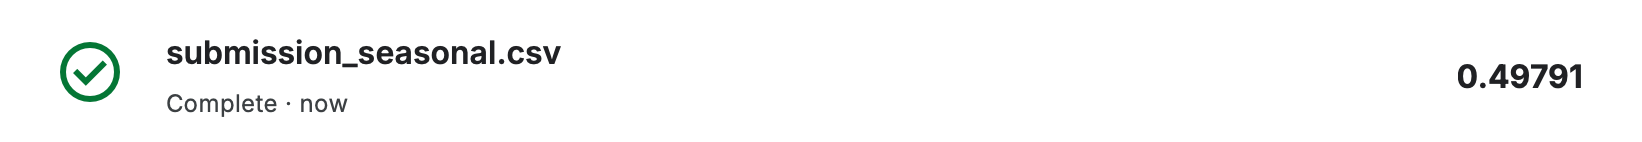

## Holiday Model


We now add holiday dummies to the selected seasonal model and validate the combined feature set before creating the final submission.

In [8]:
# The selected seasonal design with holiday/event indicators.
fourier_holidays = CalendarFourier(freq='ME', order=1)

# Submission: refit the holiday model on all 2017 data, then forecast the test dates.
dp_holidays = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier_holidays],
    drop=True,
)
X_holiday_model = add_holiday_features(dp_holidays.in_sample())

model_holidays = LinearRegression(fit_intercept=False)
model_holidays.fit(X_holiday_model, y)

df_test_holidays = pd.read_csv(
    'data/test.csv',
    dtype={
        'store_nbr': 'category',
        'family': 'category',
        'onpromotion': 'uint32',
    },
    parse_dates=['date']
)
df_test_holidays['date'] = df_test_holidays.date.dt.to_period('D')
df_test_holidays = df_test_holidays.set_index(['store_nbr', 'family', 'date']).sort_index()

test_dates = df_test_holidays.index.get_level_values('date').unique().sort_values()
X_test_holidays = add_holiday_features(dp_holidays.out_of_sample(steps=len(test_dates)))
X_test_holidays.index.name = 'date'

y_submit_holidays = pd.DataFrame(
    model_holidays.predict(X_test_holidays),
    index=X_test_holidays.index,
    columns=y.columns,
).clip(lower=0)
y_submit_holidays = y_submit_holidays.stack(['store_nbr', 'family'])
y_submit_holidays = y_submit_holidays.join(df_test_holidays.id).reindex(columns=['id', 'sales'])
y_submit_holidays = y_submit_holidays.sort_values('id')
y_submit_holidays.to_csv('submission_holidays.csv', index=False)
y_submit_holidays.head()


id        sales
date       store_nbr family                          
2017-08-16 1         AUTOMOTIVE  3000888     4.493549
                     BABY CARE   3000889     0.000000
                     BEAUTY      3000890     3.573596
                     BEVERAGES   3000891  2416.667094
                     BOOKS       3000892     0.463357

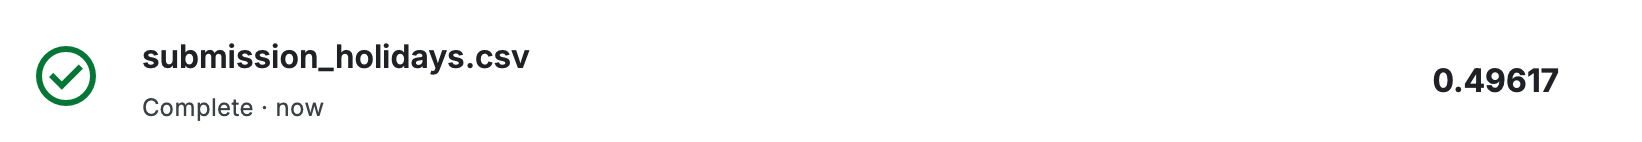

# Conclusion
This notebook shows that deterministic calendar features can produce a compact, interpretable sales forecasting model. The seasonal regression improves over a same-weekday baseline on the validation window, while holiday indicators add event awareness for the final submission.

Main limitations:

- The model uses only calendar structure and does not yet use `onpromotion`, oil prices, transactions, or store metadata.
- The validation period is short, so model rankings may be sensitive to this particular two-week window.
- Holiday features are date-level indicators; regional effects are not fully localized to the matching stores.
- A single global feature design is applied across all store-family pairs, even though some product families may have different seasonal behavior.

Recommended improvements:

- Add `onpromotion` as a covariate, since promotions can directly affect demand.
- Test store-level and family-level features from `data/stores.csv` and `data/transactions.csv`.
- Compare against lag-based machine learning models or a hierarchical approach that can share information across related series.
